In [1]:
import mne
import tensorly as tl

tl.set_backend('numpy')

print(mne.get_config_path())
print(mne.get_config('MNE_DATA'))
print(mne.get_config('MOABB_RESULTS'))
print(tl.get_backend())
%pip freeze | grep moabb

/user/leuven/352/vsc35289/.mne/mne-python.json
/scratch/leuven/352/vsc35289/mne_data
/data/leuven/352/vsc35289/moabb_results
numpy
moabb==1.1.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
from moabb.paradigms import MotorImagery, LeftRightImagery
from moabb.datasets import *
from moabb.evaluations import WithinSessionEvaluation

sfreq=250


datasets = [
    (MotorImagery(resample=sfreq), AlexMI()),
    #(LeftRightImagery(), BNCI2014_004()),
]


Choosing from all possible events


In [3]:
from sklearn.pipeline import Pipeline
from hoda.hoda import HODA, BTTDA,  GreedyBTTDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from hoda.classification import ToeplitzLDAWrapper,ZScore
from sklearn.preprocessing import StandardScaler
from mne.decoding import Scaler
from sklearn.linear_model import LogisticRegression
from hoda.tensorize import  Vectorize, Tensorize
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import StratifiedKFold

pipelines=dict()

cv=StratifiedKFold(random_state=42, shuffle=True)


hoda_params = dict(
    max_iter=128,
    tol=1e-6,
    init ='random',
    random_state=42,
    shrinkage='lw',
    solver='lanczos',
    taper=False,
    forward=False,
    obj='tr',
    toeplitz=None,
    delta=None,
    extra_train_info=False,
)

bttda_params=dict(
        truncate=True,
        n_jobs=5,
        hoda_params=hoda_params,
        extra_train_info=False,
        verbose=False,
        select=True,
        cv=cv,
)

pipelines['HODA'] = Pipeline([
    ('zscore1', ZScore()),
    ('bttda', GreedyBTTDA(
        max_blocks=1,
        **bttda_params,
    )),
    ('zscore2', StandardScaler()),
    ('lda', LDA(shrinkage='auto', solver='lsqr'))
])

pipelines['PARAFACDA_10'] = Pipeline([
    ('zscore1', ZScore()),
    ('bttda', GreedyBTTDA(
        max_blocks=10,
        rank_grid=[1],
        **bttda_params,
    )),
    ('zscore2', StandardScaler()),
    ('lda', LDA(shrinkage='auto', solver='lsqr'))
])

pipelines['BTTDA_10'] = Pipeline([
    ('zscore1', ZScore()),
    ('bttda', GreedyBTTDA(
        max_blocks=10,
        **bttda_params,
    )),
    ('zscore2', StandardScaler()),
    ('lda', LDA(shrinkage='auto', solver='lsqr'))
])

In [4]:
import pandas as pd
from sklearn.preprocessing import FunctionTransformer
from hoda.tensorize import stf_tensor

post_pipe = FunctionTransformer(stf_tensor, kw_args=dict(sfreq=sfreq, zscore=False))
results = []
for paradigm, dataset in datasets:
    print(dataset.code)
    evaluation = WithinSessionEvaluation(
        paradigm=paradigm,
        datasets=[dataset],
        overwrite=False,
        random_state=42,
        n_jobs=5,
        suffix=f'bttda_{dataset.code}',
    )
    results.append(evaluation.process(pipelines,postprocess_pipeline=post_pipe))
results = pd.concat(results)

AlexandreMotorImagery


AlexandreMotorImagery-WithinSession:   0%|          | 0/8 [00:00<?, ?it/s]


In [5]:
results

,score,time,samples,subject,session,channels,n_sessions,dataset,pipeline
0,0.400000,139.831848,60.0,1,0,16,1,AlexandreMotorImagery,BTTDA_10
1,0.383333,126.722069,60.0,2,0,16,1,AlexandreMotorImagery,BTTDA_10
2,0.433333,137.778625,60.0,3,0,16,1,AlexandreMotorImagery,BTTDA_10
3,0.533333,91.956795,60.0,4,0,16,1,AlexandreMotorImagery,BTTDA_10
4,0.566667,130.265656,60.0,5,0,16,1,AlexandreMotorImagery,BTTDA_10
5,0.416667,144.639648,60.0,6,0,16,1,AlexandreMotorImagery,BTTDA_10
6,0.550000,143.371796,60.0,7,0,16,1,AlexandreMotorImagery,BTTDA_10
7,0.516667,112.590073,60.0,8,0,16,1,AlexandreMotorImagery,BTTDA_10
8,0.316667,31.156282,60.0,1,0,16,1,AlexandreMotorImagery,PARAFACDA_10
9,0.383333,24.793465,60.0,2,0,16,1,AlexandreMotorImagery,PARAFACDA_10


In [6]:
#results.to_csv('moabb_results_mi.csv')

In [7]:
results.groupby(['dataset','session', 'pipeline'])['score'].aggregate('mean') 

dataset                session  pipeline    
AlexandreMotorImagery  0        BTTDA_10        0.47500
                                HODA            0.43125
                                PARAFACDA_10    0.41250
Name: score, dtype: float32

dataset                session  pipeline    
AlexandreMotorImagery  0        BTTDA_10        0.074001
                                HODA            0.095301
                                PARAFACDA_10    0.144131
Name: score, dtype: float32

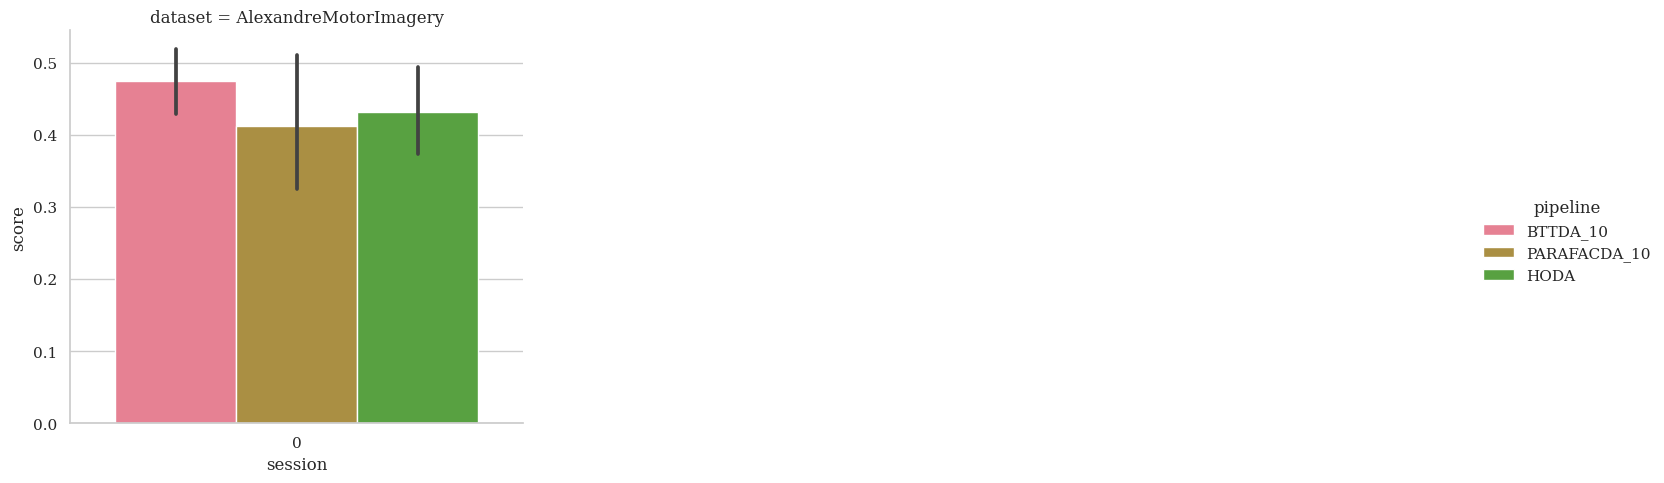

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

order = results.groupby('pipeline')
order = order.score.aggregate('mean')
order = order.sort_values()


sns.catplot(data=results , x='session', y='score', col='dataset',hue='pipeline', col_wrap=3,kind='bar')
plt.show()

/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/analysis/plotting.py:212: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot_df.loc[row, col] = txt
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/analysis/plotting.py:212: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.76
p=3e-02' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot_df.loc[row, col] = txt
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/analysis/plotting.py:212: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.57
p=7e-02' has dtype incomp

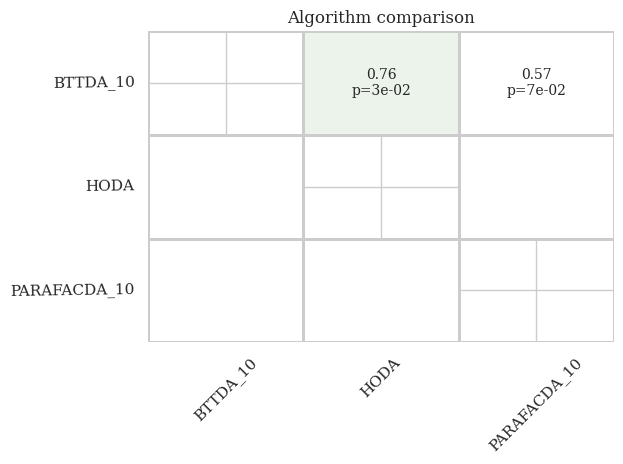

In [10]:
from moabb.analysis.meta_analysis import compute_dataset_statistics, find_significant_differences
from moabb.analysis.plotting import summary_plot
import matplotlib.pyplot as plt

stats = compute_dataset_statistics(results)
P, T = find_significant_differences(stats)
_ = summary_plot(P, T)
plt.show()